In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile
from skimage.io import imread
from tnia.plotting.plt_helper import mask_outline_overlay

from napari_ai_lab.models.image_data_model import ImageDataModel
from napari_ai_lab.Segmenters.GlobalSegmenters.Cellpose3SkopSegmenter import (
    Cellpose3SkopSegmenter,
)
from napari_ai_lab.Segmenters.GlobalSegmenters.Cellpose4SkopSegmenter import (
    Cellpose4SkopSegmenter,
)

plt.rcParams["figure.dpi"] = 72

ARCH = "cellpose3"  # 'cellposedino', 'cellposesam' or 'cellpose3'.
SEGMENTER, INITIAL_MODEL, BATCH = {
    "cellposedino": (Cellpose4SkopSegmenter, "cpdino_vitb", 1),
    "cellposesam": (Cellpose4SkopSegmenter, "cpsam_v2", 1),
    "cellpose3": (Cellpose3SkopSegmenter, "cyto3", 8),
}[ARCH]


PROJECT = Path("data/bees").resolve()

In [2]:
segmenter = SEGMENTER()                          # from the ARCH dict
segmenter.model_save_dir = str(PROJECT / "models")
segmenter.set_model(f"bees_{ARCH}")              # same name train() writes

In [3]:
# train() points inference at the model it just wrote.
print("segmenting with", segmenter.inference_model_name)

results = {}
for path in sorted(PROJECT.glob("comb_*.png")):
    image = imread(path)[..., :3]
    masks = segmenter.segment(image)
    results[path.stem] = (image, masks)
    print(f"{path.stem}: {int(masks.max())} bees")

segmenting with bees_cellpose3
comb_01: 184 bees
comb_02: 388 bees
comb_03: 27 bees
comb_04: 85 bees
comb_05: 756 bees
comb_06: 649 bees
comb_07: 313 bees


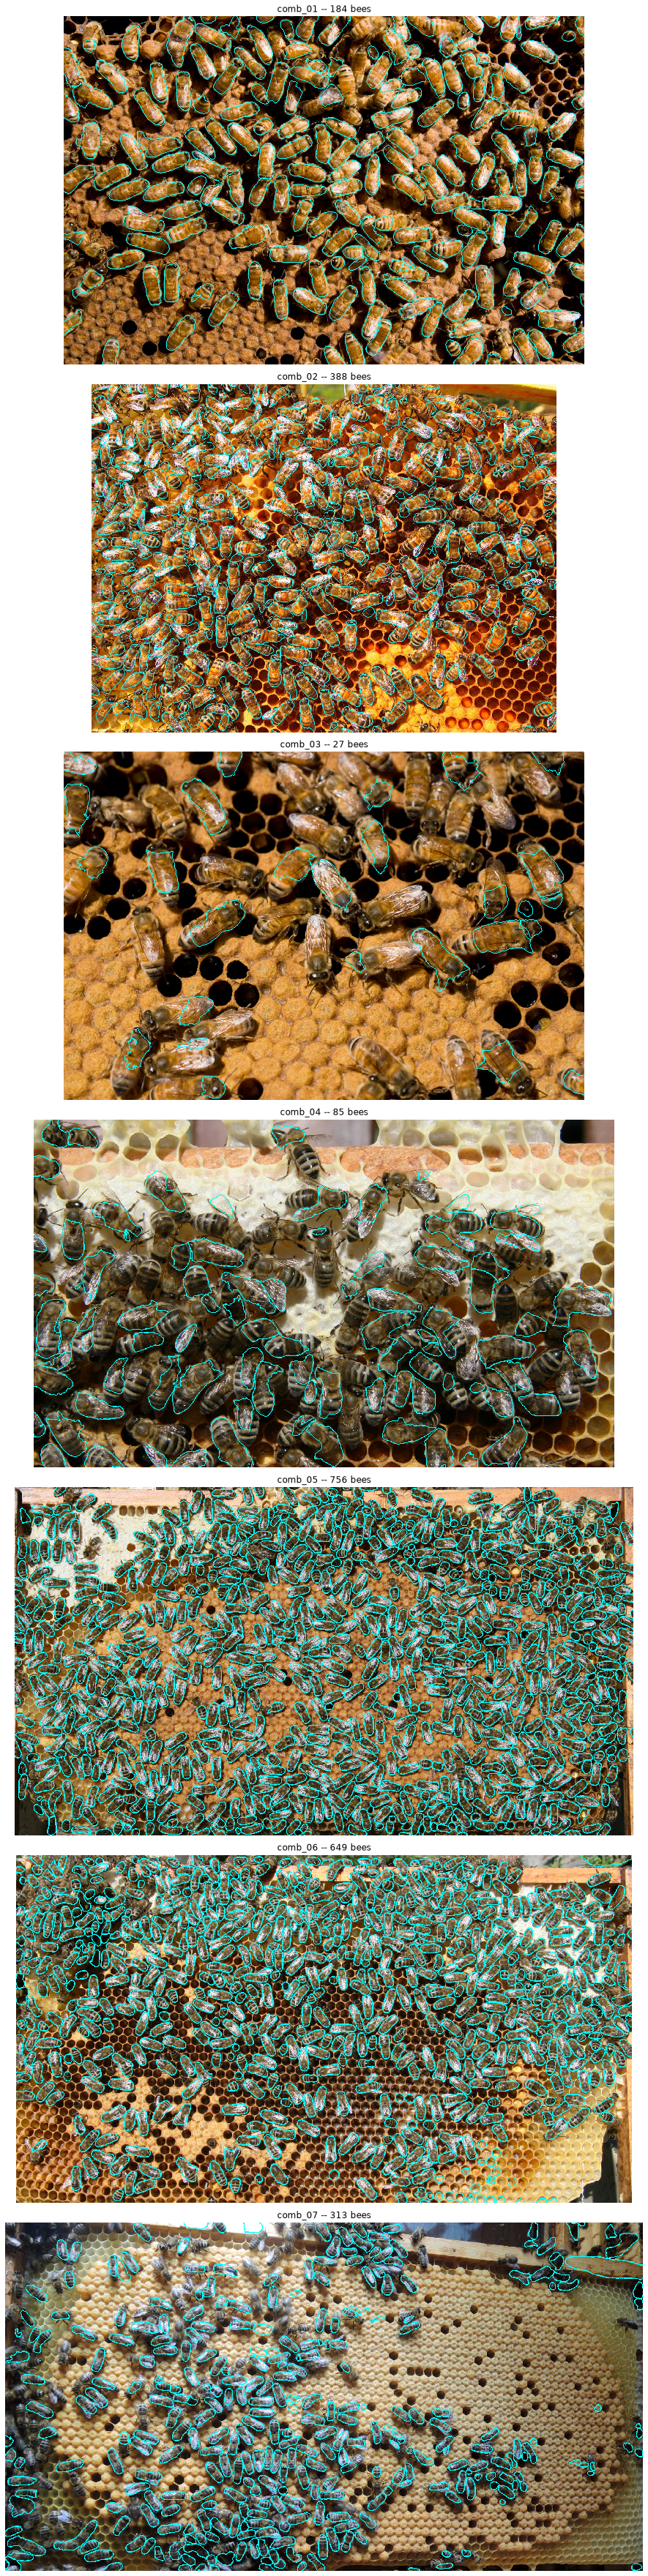

In [4]:
fig, axes = plt.subplots(len(results), 1, figsize=(13, 7 * len(results)))
for ax, (name, (image, masks)) in zip(np.atleast_1d(axes), results.items()):
    ax.imshow(mask_outline_overlay(image, masks))
    ax.set_title(f"{name} -- {int(masks.max())} bees")
    ax.axis("off")
fig.tight_layout()